# Comprehensive Analysis: Genre Impact & Text Quality

Compare the **new local JSONL** (`data/wikipedia_synthetic.jsonl` — includes new genres) against the **published HuggingFace dataset** (`alexneakameni/ZSHOT-HARDSET-v2`).

Covers: genre distributions, word frequency, vocabulary diversity, label analysis, text quality, n-grams, lexical richness, and cross-dataset statistical tests.

## 1. Import Required Libraries

In [1]:
import json, re, math, warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats as sp_stats
from datasets import load_dataset

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
pd.set_option("display.max_colwidth", 80)

# ── Stopwords (lightweight, no nltk download needed) ──
STOPWORDS = set(
    "a an the and or but in on at to for of is it this that was were be been "
    "being have has had do does did will would shall should may might can could "
    "not no nor so if then than too very just about above after again all also "
    "am any are as between both by down during each few from further get got he "
    "her here hers herself him himself his how i its itself let me more most my "
    "myself now off once only other our ours ourselves out over own re s same she "
    "some such t them themselves there these they their theirs through under "
    "until up us we what when where which while who whom why with you your yours "
    "yourself yourselves d ll m o ve".split()
)

DATA_DIR = Path("..") / "data"
JSONL_PATH = DATA_DIR / "wikipedia_synthetic.jsonl"
HF_DATASET = "alexneakameni/ZSHOT-HARDSET-v2"

print(f"JSONL path: {JSONL_PATH.resolve()}")
print(f"HF dataset: {HF_DATASET}")

JSONL path: /data/home/eak/learning/library/hierachy/generate-gliznet-data/data/wikipedia_synthetic.jsonl
HF dataset: alexneakameni/ZSHOT-HARDSET-v2


## 2. Load Data Sources

In [4]:
# ── Load local JSONL ──
df_local = pd.read_json(JSONL_PATH, lines=True)
df_local["_origin"] = "local_new"

# ── Load HuggingFace dataset ──
hf_ds = load_dataset(HF_DATASET, split="train")
df_hf = hf_ds.to_pandas()
df_hf["_origin"] = "hf_published"

# Ensure labels columns are plain lists (HF may store as sequences/arrays)
for col in ("labels", "not_labels"):
    for df in (df_local, df_hf):
        df[col] = df[col].apply(lambda x: list(x) if not isinstance(x, list) else x)

# ── Derive helper columns for both ──
def enrich(df):
    df["n_pos"] = df["labels"].apply(len)
    df["n_neg"] = df["not_labels"].apply(len)
    df["text_words"] = df["text"].str.split().apply(len)
    df["text_chars"] = df["text"].str.len()
    df["n_sentences"] = df["text"].apply(lambda t: max(len(re.split(r'[.!?]+', t.strip())) - 1, 1))
    df["all_labels"] = [pos + neg for pos, neg in zip(df["labels"].tolist(), df["not_labels"].tolist())]
    df["n_all_labels"] = df["all_labels"].apply(len)
    return df

df_local = enrich(df_local)
df_hf = enrich(df_hf)

# ── Combined for cross-dataset comparisons ──
df_all = pd.concat([df_hf, df_local], ignore_index=True)

print(f"Local  (new):   {len(df_local):>8,} rows  |  {df_local['genre'].nunique()} genres")
print(f"HF (published): {len(df_hf):>8,} rows  |  {df_hf['genre'].nunique() if 'genre' in df_hf.columns else 'N/A'} genres")
print(f"Combined:       {len(df_all):>8,} rows")
display(df_local.head(3))

Local  (new):    250,307 rows  |  105 genres
HF (published): 1,315,497 rows  |  N/A genres
Combined:       1,565,804 rows


,source,genre,language_level,text,labels,not_labels,_origin,n_pos,n_neg,text_words,text_chars,n_sentences,all_labels,n_all_labels
0,wikipedia,maturity or readiness assessment,C1,"The nascent collaboration framework, while possessing theoretical rigor, rem...","[nascent_initiative, experimental_phase]","[established_infrastructure, advanced_implementation, operational_maturity, ...",local_new,2,5,25,216,1,"[nascent_initiative, experimental_phase, established_infrastructure, advance...",7
1,wikipedia,maturity or readiness assessment,C1,"Currently navigating the early stages of refinement, the pilot program exhib...","[early_stage_development, methodological_refinement, scaling_potential]","[established_infrastructure, advanced_implementation, institutional_integrat...",local_new,3,5,25,188,1,"[early_stage_development, methodological_refinement, scaling_potential, esta...",8
2,wikipedia,maturity or readiness assessment,C1,"Having successfully weathered initial hurdles, the current operational model...","[operational_maturity, institutional_integration, network_consolidation]","[nascent_initiative, early_stage_development, experimental_phase, critical_v...",local_new,3,5,23,196,1,"[operational_maturity, institutional_integration, network_consolidation, nas...",8


## 3. Basic Dataset Statistics

In [5]:
numeric_cols = ["n_pos", "n_neg", "text_words", "text_chars", "n_sentences", "n_all_labels"]

for tag, df in [("LOCAL (new genres)", df_local), ("HF (published)", df_hf)]:
    print(f"\n{'═'*60}")
    print(f"  {tag}  —  {len(df):,} rows")
    print(f"{'═'*60}")
    print(f"  Columns:       {list(df.columns)}")
    print(f"  Duplicate texts: {df['text'].duplicated().sum():,}")
    print(f"  Empty labels:    {(df['n_pos'] == 0).sum():,}")
    print(f"  Empty not_labels:{(df['n_neg'] == 0).sum():,}")
    all_pos = [l for ls in df["labels"] for l in ls]
    all_neg = [l for ls in df["not_labels"] for l in ls]
    print(f"  Unique pos labels:  {len(set(all_pos)):,}")
    print(f"  Unique neg labels:  {len(set(all_neg)):,}")
    print(f"  Unique all labels:  {len(set(all_pos) | set(all_neg)):,}")
    print()
    display(df[numeric_cols].describe().round(2))


════════════════════════════════════════════════════════════
  LOCAL (new genres)  —  250,307 rows
════════════════════════════════════════════════════════════
  Columns:       ['source', 'genre', 'language_level', 'text', 'labels', 'not_labels', '_origin', 'n_pos', 'n_neg', 'text_words', 'text_chars', 'n_sentences', 'all_labels', 'n_all_labels']
  Duplicate texts: 1
  Empty labels:    0
  Empty not_labels:0
  Unique pos labels:  397,742
  Unique neg labels:  418,783
  Unique all labels:  440,430



,n_pos,n_neg,text_words,text_chars,n_sentences,n_all_labels
count,250307.00,250307.00,250307.00,250307.00,250307.00,250307.00
mean,3.80,9.23,41.72,276.89,2.47,13.03
std,0.67,2.62,25.96,180.12,1.63,2.65
min,1.00,1.00,1.00,23.00,1.00,5.00
25%,3.00,8.00,22.00,145.00,1.00,12.00
50%,4.00,10.00,30.00,201.00,2.00,14.00
75%,4.00,11.00,58.00,381.00,4.00,15.00
max,14.00,15.00,210.00,1453.00,20.00,20.00



════════════════════════════════════════════════════════════
  HF (published)  —  1,315,497 rows
════════════════════════════════════════════════════════════
  Columns:       ['text', 'labels', 'not_labels', 'model', '_origin', 'n_pos', 'n_neg', 'text_words', 'text_chars', 'n_sentences', 'all_labels', 'n_all_labels']
  Duplicate texts: 0
  Empty labels:    0
  Empty not_labels:0
  Unique pos labels:  1,256,196
  Unique neg labels:  1,293,270
  Unique all labels:  1,389,145



,n_pos,n_neg,text_words,text_chars,n_sentences,n_all_labels
count,1315497.00,1315497.00,1315497.00,1315497.00,1315497.00,1315497.00
mean,3.77,8.84,42.32,283.24,2.53,12.61
std,0.65,3.07,26.15,182.25,1.61,3.10
min,1.00,1.00,0.00,0.00,1.00,2.00
25%,3.00,8.00,21.00,144.00,1.00,11.00
50%,4.00,10.00,32.00,214.00,2.00,14.00
75%,4.00,11.00,59.00,393.00,4.00,15.00
max,16.00,35.00,363.00,2728.00,21.00,44.00


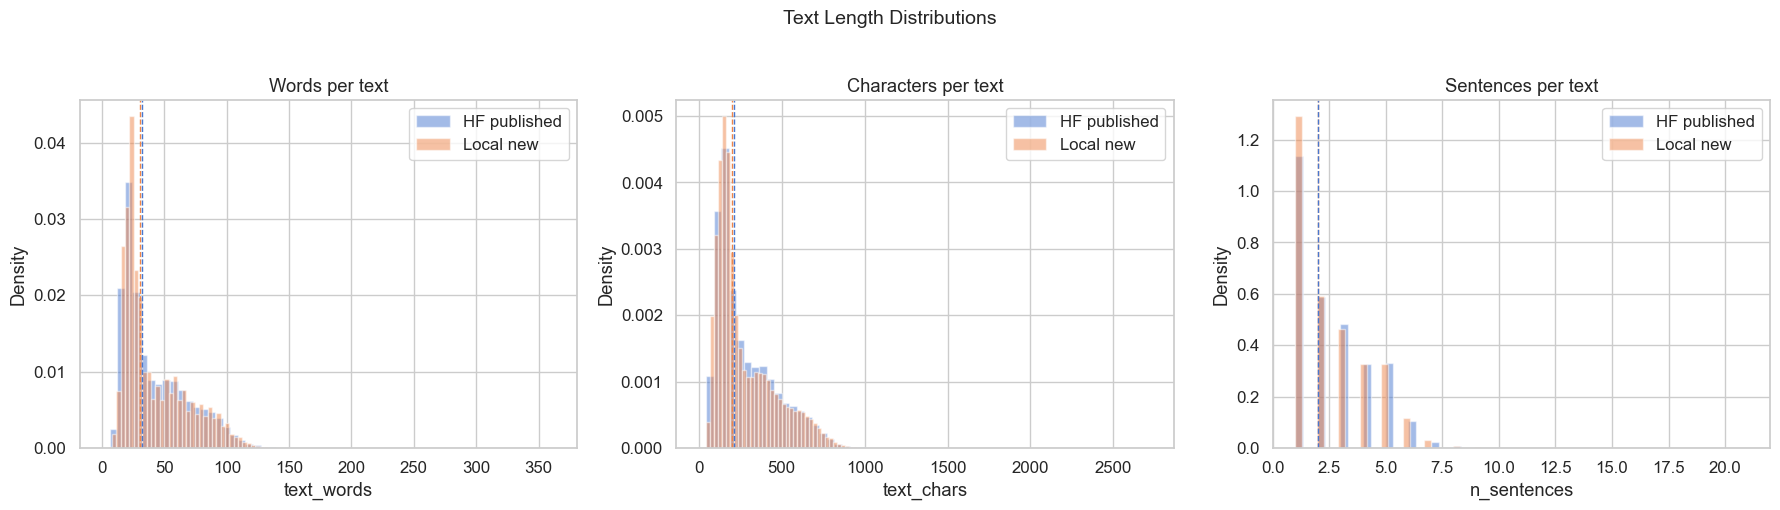

In [6]:
# ── Text-length distributions side by side ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col, title in zip(axes, ["text_words", "text_chars", "n_sentences"],
                           ["Words per text", "Characters per text", "Sentences per text"]):
    for tag, df in [("HF published", df_hf), ("Local new", df_local)]:
        ax.hist(df[col], bins=60, alpha=0.5, label=tag, density=True)
    ax.set(title=title, xlabel=col, ylabel="Density")
    ax.legend()
    ax.axvline(df_local[col].median(), color="C1", ls="--", lw=1)
    ax.axvline(df_hf[col].median(), color="C0", ls="--", lw=1)
fig.suptitle("Text Length Distributions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. Genre Distribution Analysis

Only the local dataset has genre metadata. We look at balance, entropy, and new vs original genres.

Total genres:  105
New genres:    15 (37,550 rows = 15.0%)
Original:      90 (212,757 rows)

Genre entropy:     6.712 bits  (max 6.714 → 100.0% of uniform)


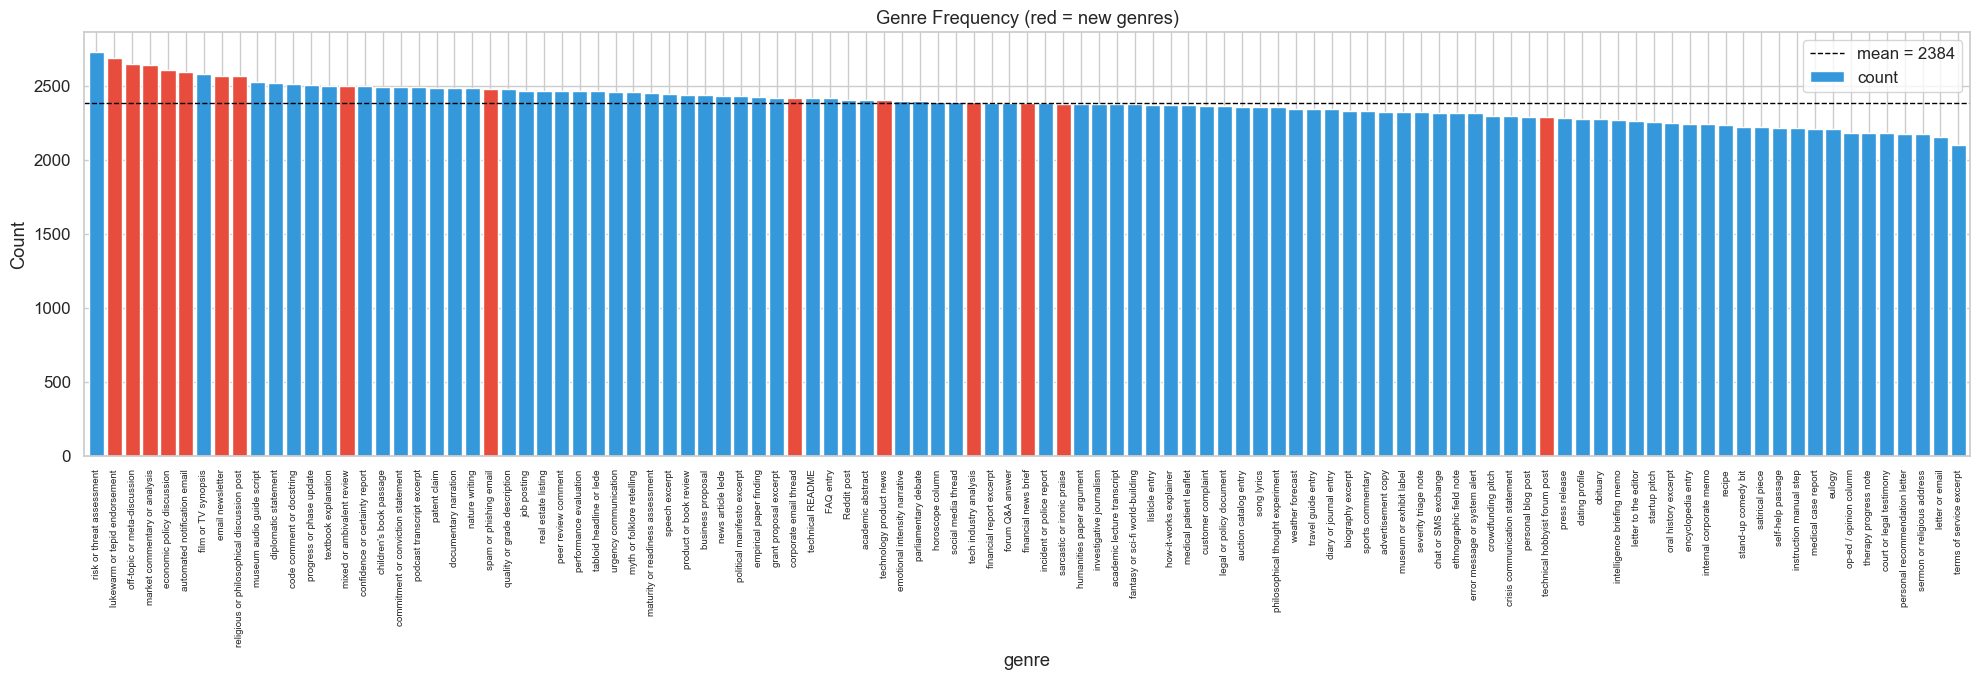

In [7]:
# ── New genres added in the latest batch ──
NEW_GENRES = {
    # Email Domain
    "email newsletter", "spam or phishing email", "corporate email thread", "automated notification email",
    # Fine-Grained Sentiment
    "mixed or ambivalent review", "lukewarm or tepid endorsement", "sarcastic or ironic praise",
    # Topic-Forum Discourse
    "technical hobbyist forum post", "religious or philosophical discussion post", "off-topic or meta-discussion",
    # Financial & Market
    "market commentary or analysis", "financial news brief", "economic policy discussion",
    # Tech vs Business
    "technology product news", "tech industry analysis",
}

genre_counts = df_local["genre"].value_counts()
df_local["is_new_genre"] = df_local["genre"].isin(NEW_GENRES)

print(f"Total genres:  {len(genre_counts)}")
print(f"New genres:    {len(NEW_GENRES)} ({df_local['is_new_genre'].sum():,} rows = {df_local['is_new_genre'].mean()*100:.1f}%)")
print(f"Original:      {len(genre_counts) - len(NEW_GENRES)} ({(~df_local['is_new_genre']).sum():,} rows)")

# Shannon entropy of genre distribution (max = log2(N_genres) for uniform)
probs = genre_counts.values / genre_counts.values.sum()
entropy = -np.sum(probs * np.log2(probs))
max_entropy = np.log2(len(genre_counts))
print(f"\nGenre entropy:     {entropy:.3f} bits  (max {max_entropy:.3f} → {entropy/max_entropy*100:.1f}% of uniform)")

# Bar chart — highlight new genres
fig, ax = plt.subplots(figsize=(20, 7))
colors = ["#e74c3c" if g in NEW_GENRES else "#3498db" for g in genre_counts.index]
genre_counts.plot.bar(ax=ax, color=colors, width=0.85)
ax.set(title="Genre Frequency (red = new genres)", ylabel="Count")
ax.tick_params(axis="x", rotation=90, labelsize=7)
ax.axhline(genre_counts.mean(), color="black", ls="--", lw=1, label=f"mean = {genre_counts.mean():.0f}")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Word Frequency Analysis

Tokenize all texts, compute word frequencies, Zipf's law, and compare profiles across datasets. Both with and without stopwords.

                                      Local           HF
Total tokens                     10,503,880   56,077,056
Unique types (all)                  127,181      187,667
Unique types (no stopwords)         127,047      187,533
Hapax legomena                       54,757       67,304


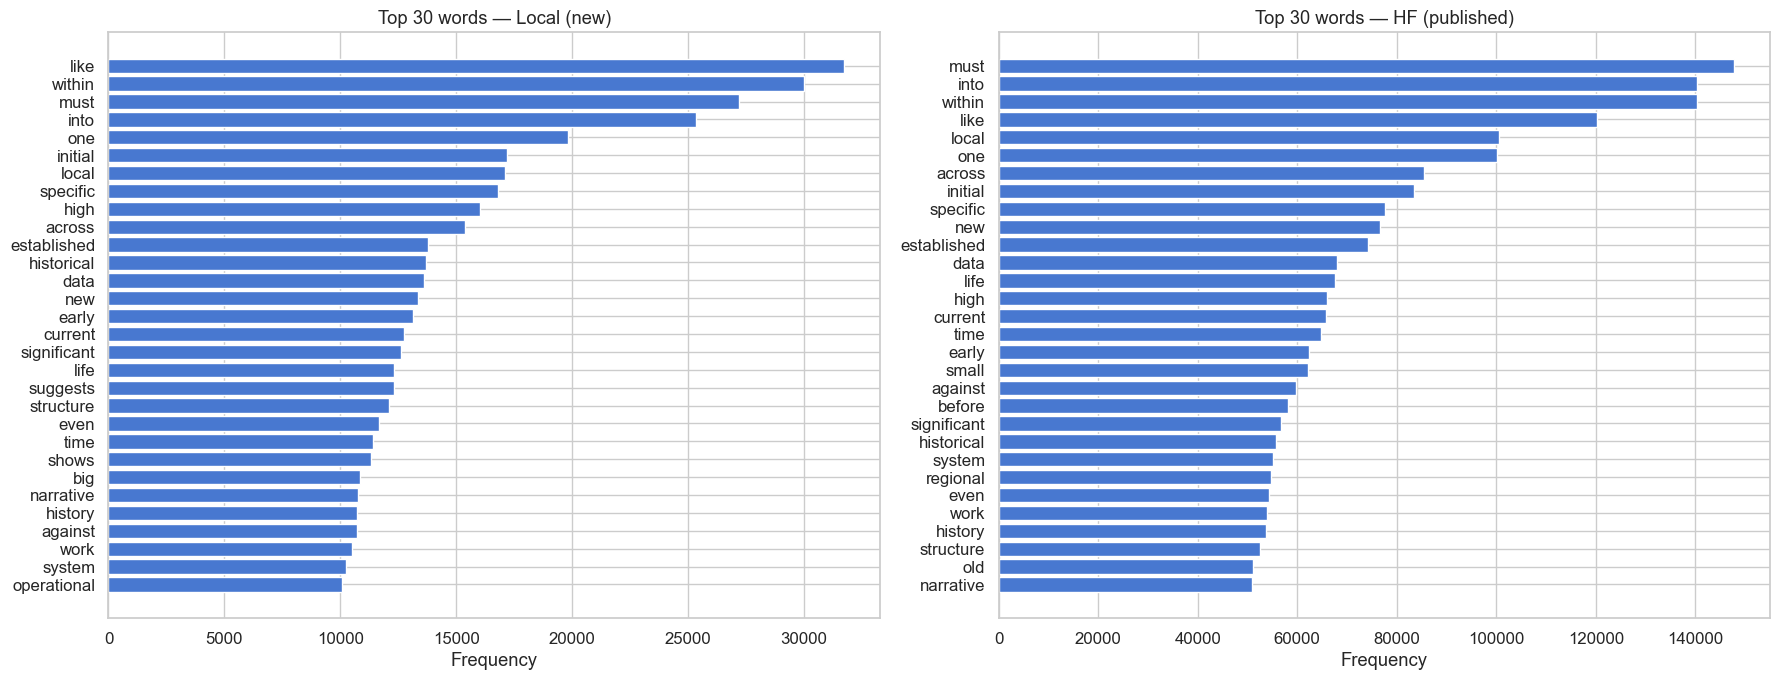

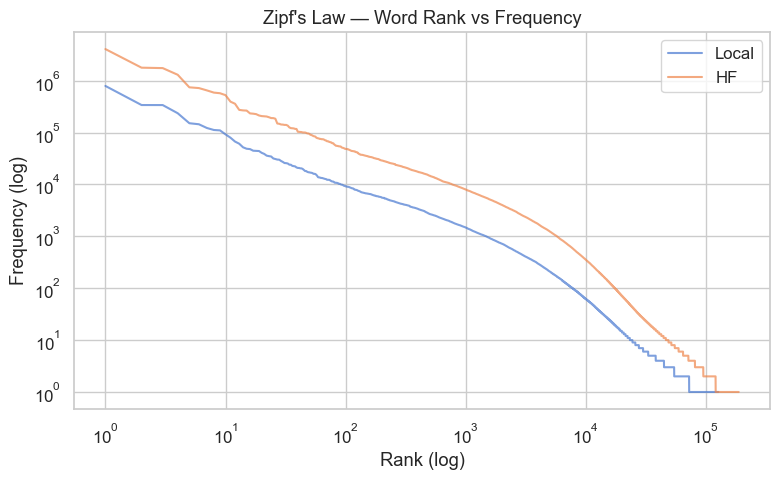

In [8]:
def tokenize_series(series):
    """Lowercase word tokenisation (alpha-only)."""
    return [w for text in series for w in re.findall(r"[a-z]+(?:'[a-z]+)?", text.lower())]

words_local = tokenize_series(df_local["text"])
words_hf    = tokenize_series(df_hf["text"])

freq_local = Counter(words_local)
freq_hf    = Counter(words_hf)

# Without stopwords
words_local_ns = [w for w in words_local if w not in STOPWORDS]
words_hf_ns    = [w for w in words_hf if w not in STOPWORDS]
freq_local_ns  = Counter(words_local_ns)
freq_hf_ns     = Counter(words_hf_ns)

print(f"{'':30s} {'Local':>12s} {'HF':>12s}")
print(f"{'Total tokens':30s} {len(words_local):>12,} {len(words_hf):>12,}")
print(f"{'Unique types (all)':30s} {len(freq_local):>12,} {len(freq_hf):>12,}")
print(f"{'Unique types (no stopwords)':30s} {len(freq_local_ns):>12,} {len(freq_hf_ns):>12,}")
print(f"{'Hapax legomena':30s} {sum(1 for v in freq_local.values() if v==1):>12,} {sum(1 for v in freq_hf.values() if v==1):>12,}")

# ── Top 30 words (no stopwords) side by side ──
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, freq, title in zip(axes, [freq_local_ns, freq_hf_ns], ["Local (new)", "HF (published)"]):
    top = freq.most_common(30)
    ax.barh([w for w, _ in top][::-1], [c for _, c in top][::-1])
    ax.set(title=f"Top 30 words — {title}", xlabel="Frequency")
plt.tight_layout()
plt.show()

# ── Zipf's law ──
fig, ax = plt.subplots(figsize=(8, 5))
for freq, label in [(freq_local, "Local"), (freq_hf, "HF")]:
    ranked = sorted(freq.values(), reverse=True)
    ax.loglog(range(1, len(ranked)+1), ranked, alpha=0.7, label=label)
ax.set(title="Zipf's Law — Word Rank vs Frequency", xlabel="Rank (log)", ylabel="Frequency (log)")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Vocabulary Diversity Metrics

Type-Token Ratio (TTR), hapax ratio, and Mean Segmental TTR (MSTTR) — overall and per genre.

Metric                                     Local           HF
──────────────────────────────────────────────────────────────
TTR (all tokens)                          0.0121       0.0033
TTR (no stopwords)                        0.0196       0.0054
MSTTR (segment=1000)                      0.5587       0.5735
MSTTR no-sw (segment=1000)                0.7574       0.7756
Hapax ratio                               0.4305       0.3586
Vocabulary size                          127,181      187,667


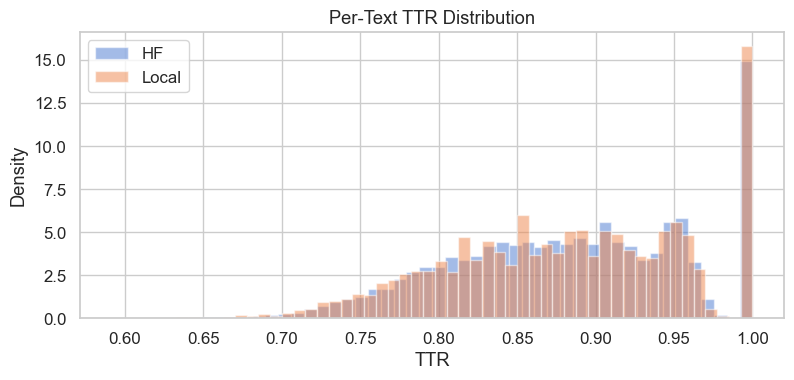

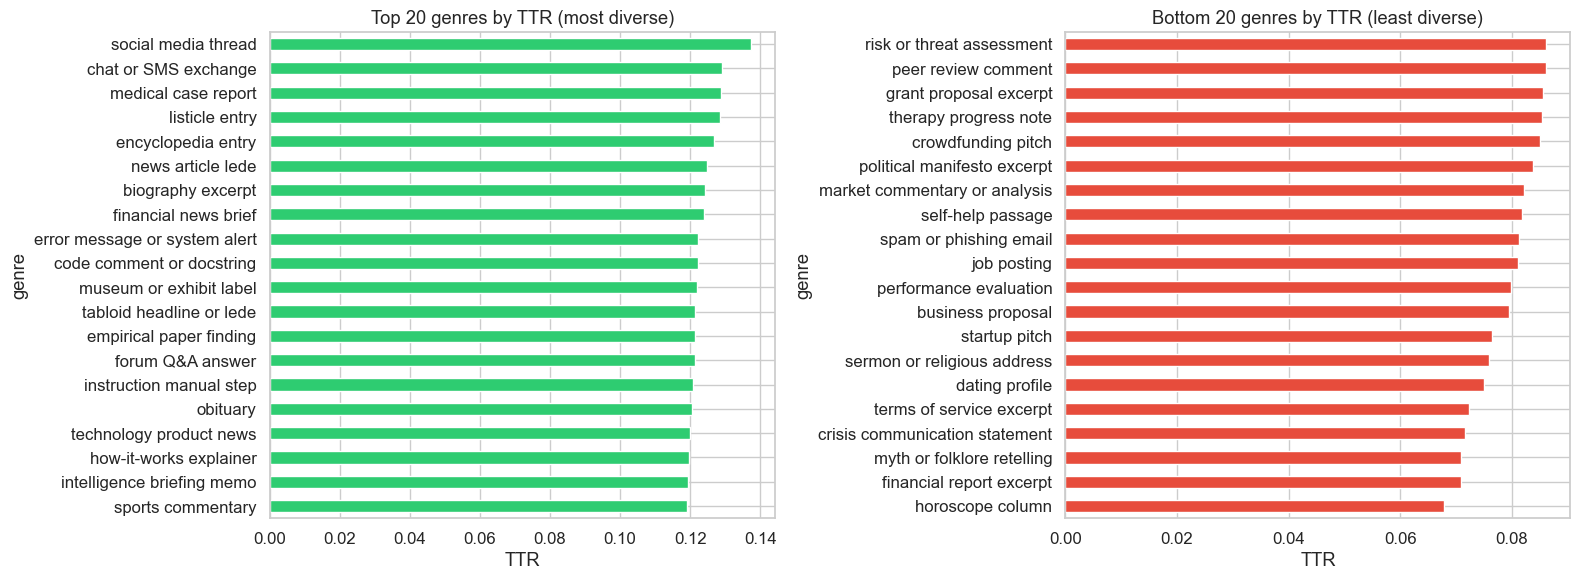

In [9]:
def ttr(tokens):
    """Type-Token Ratio."""
    return len(set(tokens)) / len(tokens) if tokens else 0

def msttr(tokens, segment_size=1000):
    """Mean Segmental TTR — average TTR over fixed-size segments."""
    segments = [tokens[i:i+segment_size] for i in range(0, len(tokens), segment_size)]
    segments = [s for s in segments if len(s) == segment_size]  # drop short tail
    return np.mean([ttr(s) for s in segments]) if segments else ttr(tokens)

def hapax_ratio(freq):
    return sum(1 for v in freq.values() if v == 1) / len(freq) if freq else 0

# ── Global diversity ──
print(f"{'Metric':35s} {'Local':>12s} {'HF':>12s}")
print("─" * 62)
print(f"{'TTR (all tokens)':35s} {ttr(words_local):>12.4f} {ttr(words_hf):>12.4f}")
print(f"{'TTR (no stopwords)':35s} {ttr(words_local_ns):>12.4f} {ttr(words_hf_ns):>12.4f}")
print(f"{'MSTTR (segment=1000)':35s} {msttr(words_local):>12.4f} {msttr(words_hf):>12.4f}")
print(f"{'MSTTR no-sw (segment=1000)':35s} {msttr(words_local_ns):>12.4f} {msttr(words_hf_ns):>12.4f}")
print(f"{'Hapax ratio':35s} {hapax_ratio(freq_local):>12.4f} {hapax_ratio(freq_hf):>12.4f}")
print(f"{'Vocabulary size':35s} {len(freq_local):>12,} {len(freq_hf):>12,}")

# ── Per-text TTR (sample for speed) ──
def per_text_ttr(df, n=10_000):
    sample = df["text"].sample(min(n, len(df)), random_state=42)
    return sample.apply(lambda t: ttr(re.findall(r"[a-z]+(?:'[a-z]+)?", t.lower())))

ttr_local = per_text_ttr(df_local)
ttr_hf    = per_text_ttr(df_hf)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ttr_hf, bins=50, alpha=0.5, label="HF", density=True)
ax.hist(ttr_local, bins=50, alpha=0.5, label="Local", density=True)
ax.set(title="Per-Text TTR Distribution", xlabel="TTR", ylabel="Density")
ax.legend()
plt.tight_layout()
plt.show()

# ── TTR by genre (local only, top 20 & bottom 20) ──
genre_ttr = df_local.groupby("genre")["text"].apply(
    lambda texts: ttr(tokenize_series(texts))
).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
genre_ttr.tail(20).plot.barh(ax=axes[0], color="#2ecc71")
axes[0].set(title="Top 20 genres by TTR (most diverse)", xlabel="TTR")
genre_ttr.head(20).plot.barh(ax=axes[1], color="#e74c3c")
axes[1].set(title="Bottom 20 genres by TTR (least diverse)", xlabel="TTR")
plt.tight_layout()
plt.show()

## 7. Label Distribution and Diversity

Shannon entropy, Simpson's diversity, Gini coefficient on label frequencies. Cross-role analysis.

,Local,HF
Unique pos labels,397742,1256196
Unique neg labels,418783,1293270
Unique all labels,440430,1389145
Cross-role labels,376095,1160321
Cross-role %,85.4%,83.5%
Only-pos labels,21647,95875
Only-neg labels,42688,132949
Shannon entropy (all),17.74,18.13
Simpson diversity (all),0.999950,0.999919
Gini coefficient (all),0.4403,0.6584


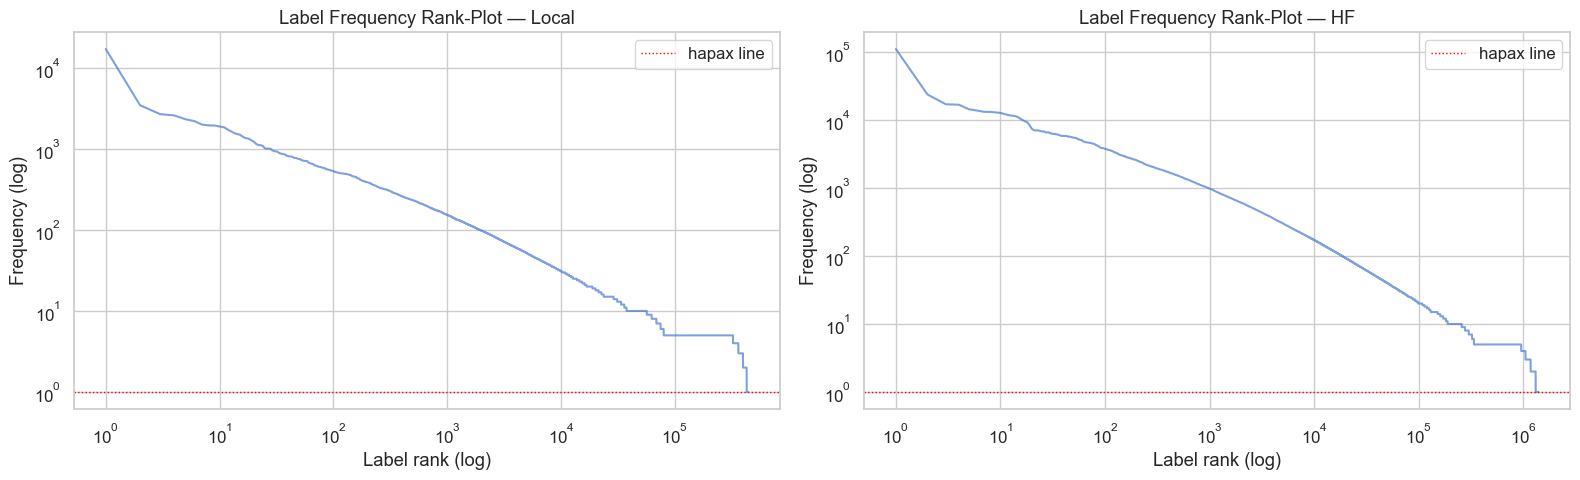

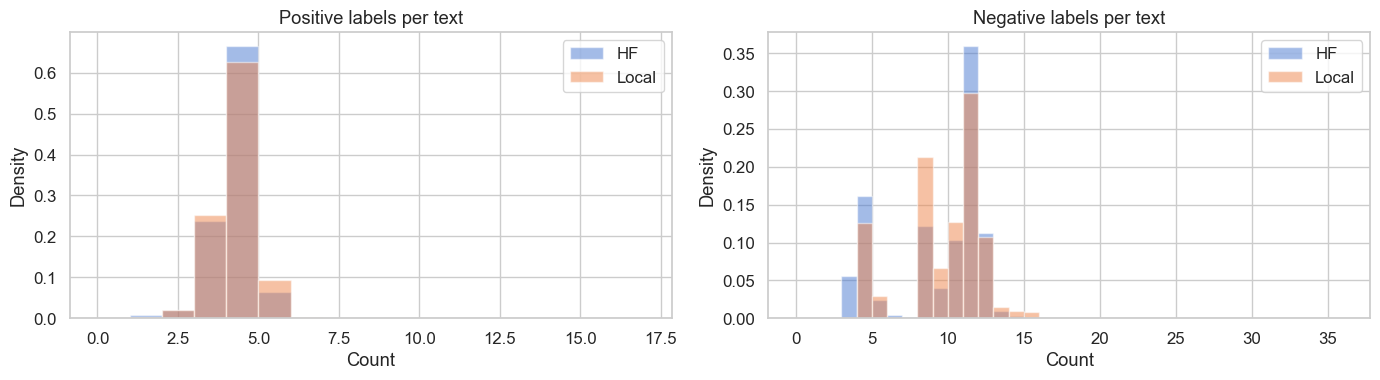

In [10]:
def shannon_entropy(counter):
    total = sum(counter.values())
    probs = np.array(list(counter.values())) / total
    return -np.sum(probs * np.log2(probs + 1e-15))

def simpson_diversity(counter):
    """1 - Simpson's index (probability two random labels differ)."""
    total = sum(counter.values())
    return 1 - sum(n*(n-1) for n in counter.values()) / (total*(total-1)) if total > 1 else 0

def gini_coefficient(counter):
    values = np.sort(np.array(list(counter.values()), dtype=float))
    n = len(values)
    idx = np.arange(1, n+1)
    return (2 * np.sum(idx * values) - (n+1) * np.sum(values)) / (n * np.sum(values)) if np.sum(values) > 0 else 0

# ── Label stats for each dataset ──
results = {}
for tag, df in [("Local", df_local), ("HF", df_hf)]:
    pos_labels = [l for ls in df["labels"] for l in ls]
    neg_labels = [l for ls in df["not_labels"] for l in ls]
    all_labels = pos_labels + neg_labels
    pos_set, neg_set = set(pos_labels), set(neg_labels)
    
    freq_pos = Counter(pos_labels)
    freq_neg = Counter(neg_labels)
    freq_all = Counter(all_labels)
    
    cross_role = pos_set & neg_set
    only_pos = pos_set - neg_set
    only_neg = neg_set - pos_set
    
    results[tag] = {
        "Unique pos labels": len(pos_set),
        "Unique neg labels": len(neg_set),
        "Unique all labels": len(pos_set | neg_set),
        "Cross-role labels": len(cross_role),
        "Cross-role %": f"{len(cross_role)/len(pos_set|neg_set)*100:.1f}%",
        "Only-pos labels": len(only_pos),
        "Only-neg labels": len(only_neg),
        "Shannon entropy (all)": f"{shannon_entropy(freq_all):.2f}",
        "Simpson diversity (all)": f"{simpson_diversity(freq_all):.6f}",
        "Gini coefficient (all)": f"{gini_coefficient(freq_all):.4f}",
        "Hapax legomena (all)": sum(1 for v in freq_all.values() if v == 1),
        "Labels freq ≥ 2": sum(1 for v in freq_all.values() if v >= 2),
    }

display(pd.DataFrame(results))

# ── Label frequency distributions ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, (tag, df) in zip(axes, [("Local", df_local), ("HF", df_hf)]):
    all_lbl = [l for ls in df["all_labels"] for l in ls]
    freq = Counter(all_lbl)
    counts = sorted(freq.values(), reverse=True)
    ax.loglog(range(1, len(counts)+1), counts, alpha=0.7)
    ax.set(title=f"Label Frequency Rank-Plot — {tag}", xlabel="Label rank (log)", ylabel="Frequency (log)")
    ax.axhline(1, color="red", ls=":", lw=1, label="hapax line")
    ax.legend()
plt.tight_layout()
plt.show()

# ── Positive vs negative label counts ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, title in zip(axes, ["n_pos", "n_neg"], ["Positive labels per text", "Negative labels per text"]):
    for tag, df in [("HF", df_hf), ("Local", df_local)]:
        ax.hist(df[col], bins=range(0, df[col].max()+2), alpha=0.5, label=tag, density=True)
    ax.set(title=title, xlabel="Count", ylabel="Density")
    ax.legend()
plt.tight_layout()
plt.show()

## 8. Text Quality Metrics

Readability approximations (Flesch-Kincaid, Coleman-Liau), avg word length, punctuation ratio, uppercase ratio, repetition rate. Per-genre breakdown for local data.

Text quality metrics (sampled):

  Local:


,avg_word_len,punct_ratio,upper_ratio,digit_ratio,flesch_kincaid,coleman_liau
count,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000
mean,5.637,0.022,0.020,0.005,13.017,14.467
std,0.884,0.010,0.018,0.012,5.131,5.450
min,3.105,0.004,0.000,0.000,-0.699,-5.593
25%,5.000,0.015,0.010,0.000,9.209,10.436
50%,5.667,0.020,0.016,0.000,13.470,14.789
75%,6.250,0.026,0.026,0.000,16.792,18.402
max,16.800,0.129,0.829,0.238,47.720,64.128



  HF:


,avg_word_len,punct_ratio,upper_ratio,digit_ratio,flesch_kincaid,coleman_liau
count,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000
mean,5.709,0.020,0.016,0.003,13.138,14.996
std,0.964,0.009,0.018,0.009,5.203,5.743
min,3.250,0.000,0.000,0.000,-0.670,-3.188
25%,5.025,0.014,0.008,0.000,9.487,10.918
50%,5.728,0.019,0.012,0.000,13.628,15.270
75%,6.333,0.024,0.019,0.000,16.762,18.936
max,40.500,0.143,0.827,0.141,126.790,178.140


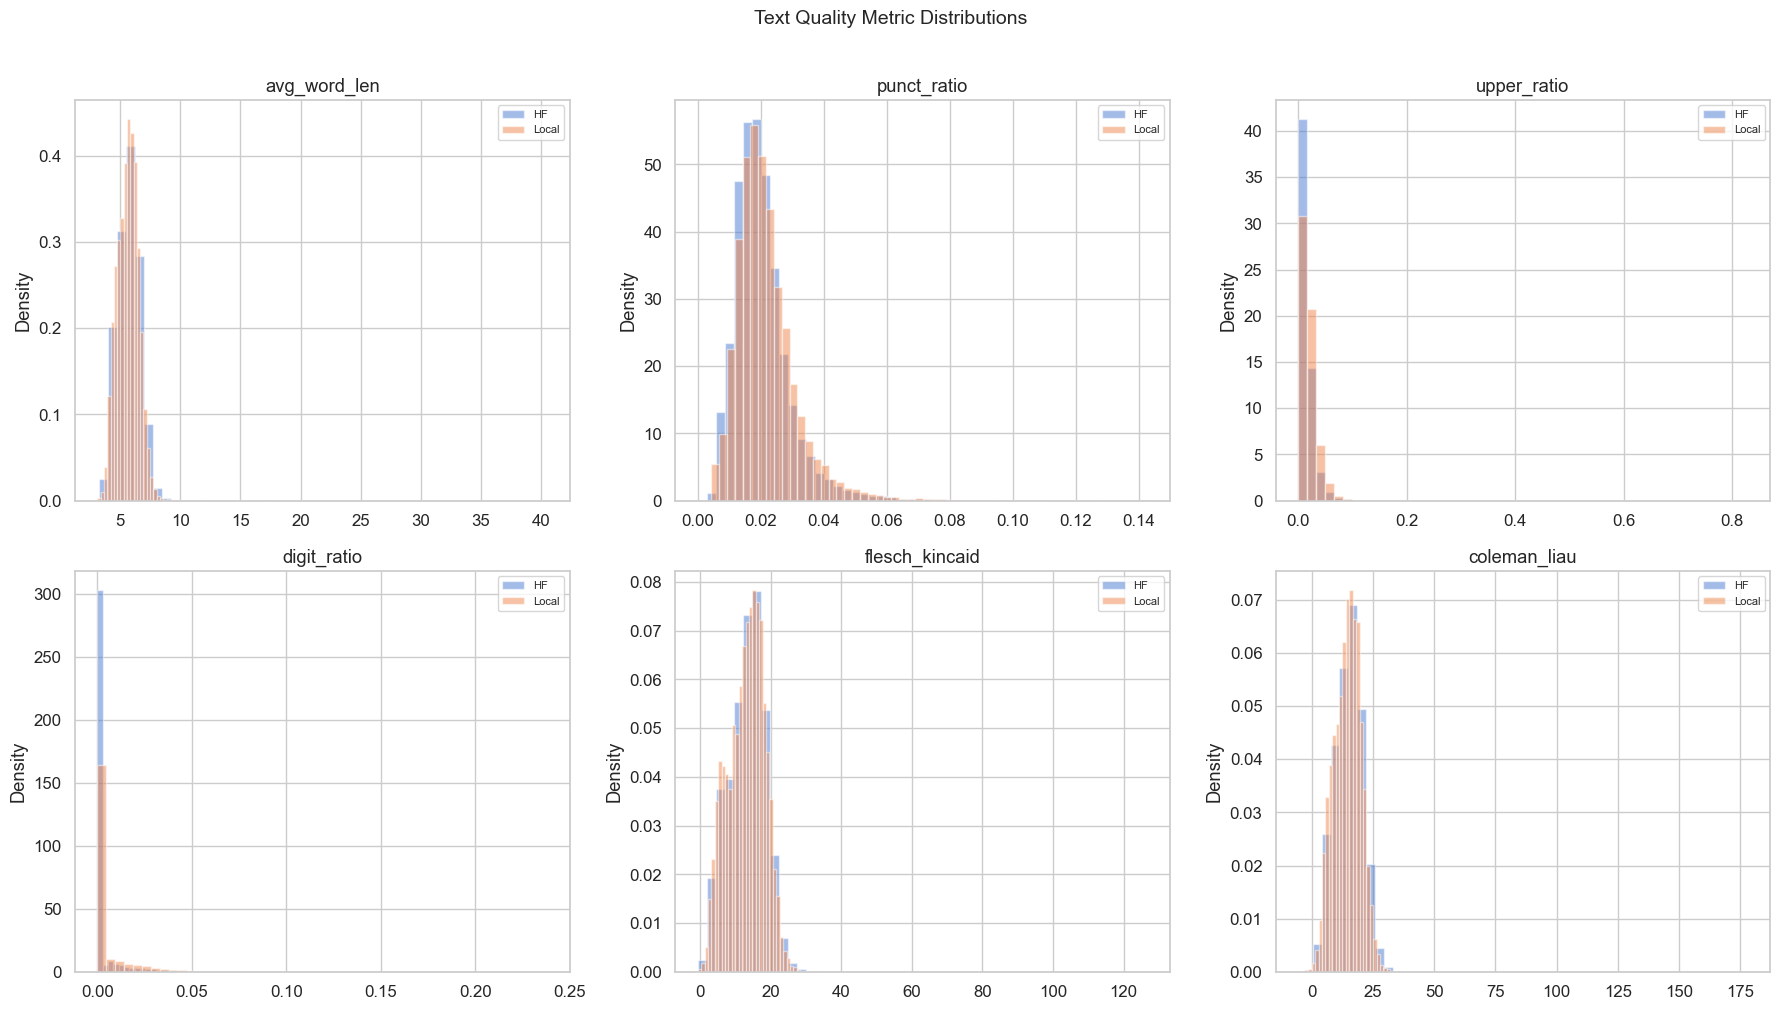

In [11]:
def count_syllables(word):
    """Rough English syllable count."""
    word = word.lower().strip()
    if len(word) <= 3:
        return 1
    word = re.sub(r'(es|ed|e)$', '', word)
    vowels = re.findall(r'[aeiouy]+', word)
    return max(1, len(vowels))

def flesch_kincaid(text):
    words = text.split()
    sents = max(len(re.split(r'[.!?]+', text.strip())) - 1, 1)
    if len(words) == 0:
        return 0
    syllables = sum(count_syllables(w) for w in words)
    return 0.39 * (len(words)/sents) + 11.8 * (syllables/len(words)) - 15.59

def coleman_liau(text):
    words = text.split()
    sents = max(len(re.split(r'[.!?]+', text.strip())) - 1, 1)
    if len(words) == 0:
        return 0
    letters = sum(c.isalpha() for c in text)
    L = letters / len(words) * 100
    S = sents / len(words) * 100
    return 0.0588 * L - 0.296 * S - 15.8

def text_quality_features(text):
    words = text.split()
    n_words = len(words) or 1
    n_chars = len(text) or 1
    return {
        "avg_word_len": np.mean([len(w) for w in words]) if words else 0,
        "punct_ratio": sum(1 for c in text if c in '.,;:!?-()[]{}"\'/') / n_chars,
        "upper_ratio": sum(1 for c in text if c.isupper()) / n_chars,
        "digit_ratio": sum(1 for c in text if c.isdigit()) / n_chars,
        "flesch_kincaid": flesch_kincaid(text),
        "coleman_liau": coleman_liau(text),
    }

# Compute on a sample for speed
SAMPLE_N = 20_000
rng = np.random.default_rng(42)

for tag, df in [("local", df_local), ("hf", df_hf)]:
    idx = rng.choice(len(df), min(SAMPLE_N, len(df)), replace=False)
    feats = df.iloc[idx]["text"].apply(lambda t: pd.Series(text_quality_features(t)))
    for col in feats.columns:
        df.loc[df.index[idx], col] = feats[col].values

# ── Summary ──
quality_cols = ["avg_word_len", "punct_ratio", "upper_ratio", "digit_ratio", "flesch_kincaid", "coleman_liau"]
print("Text quality metrics (sampled):\n")
for tag, df in [("Local", df_local), ("HF", df_hf)]:
    print(f"  {tag}:")
    display(df[quality_cols].dropna().describe().round(3))
    print()

# ── Distributions ──
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flat, quality_cols):
    for tag, df in [("HF", df_hf), ("Local", df_local)]:
        vals = df[col].dropna()
        ax.hist(vals, bins=50, alpha=0.5, label=tag, density=True)
    ax.set(title=col, ylabel="Density")
    ax.legend(fontsize=8)
fig.suptitle("Text Quality Metric Distributions", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

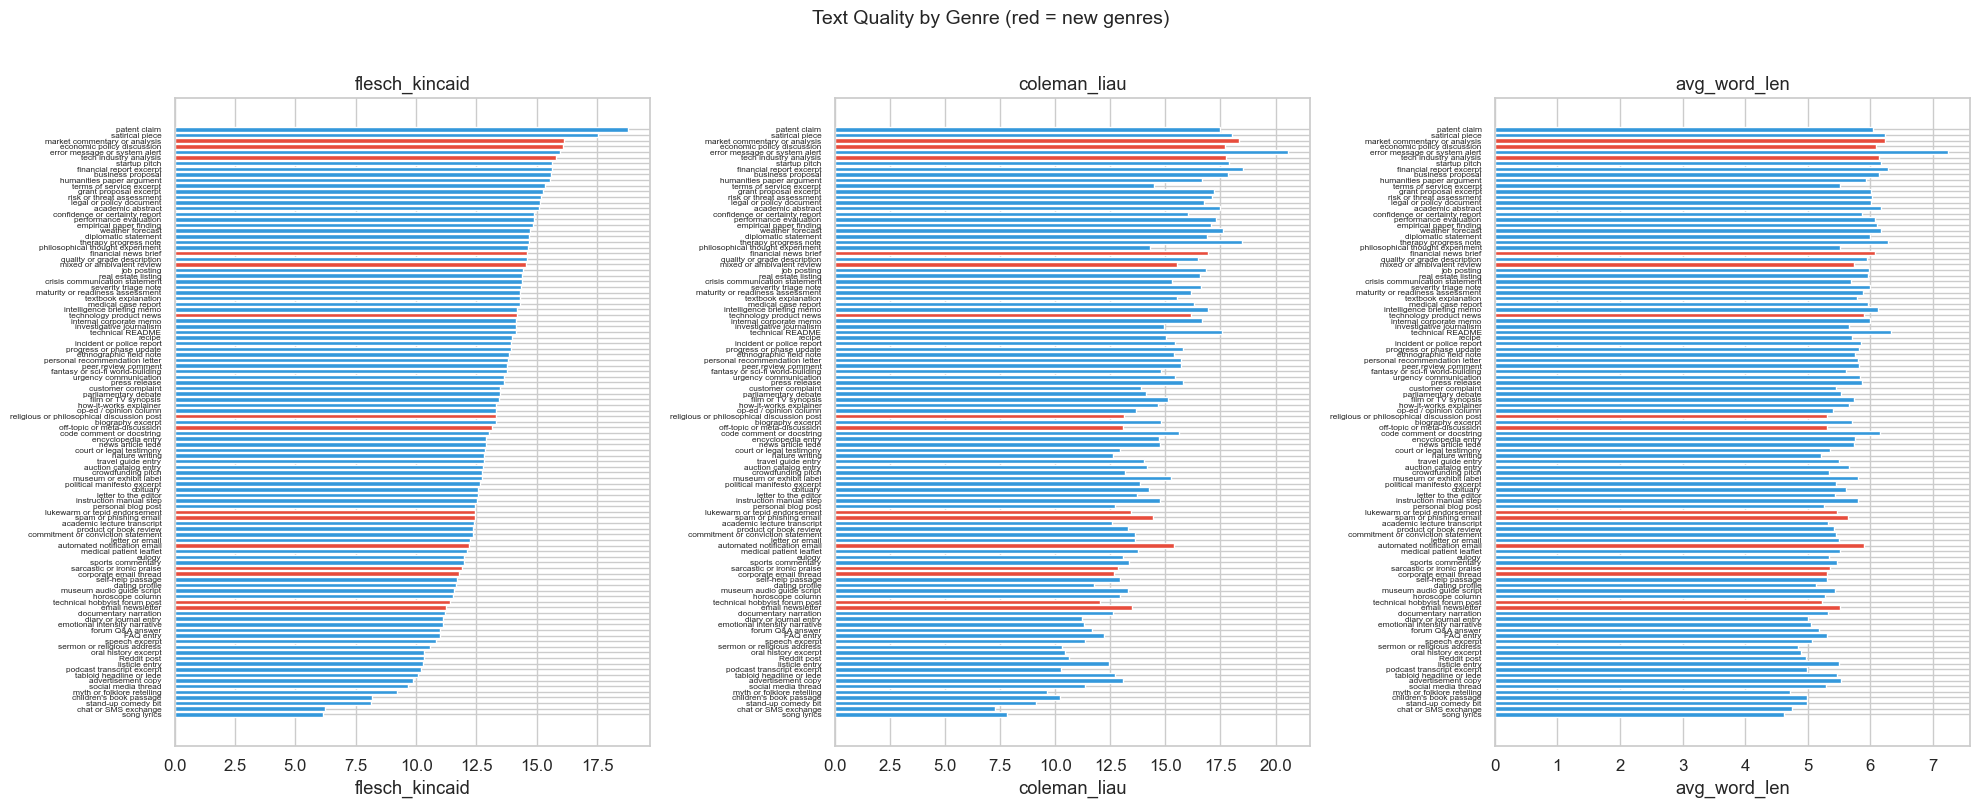

In [12]:
# ── Readability by genre (new vs original) ──
quality_by_genre = df_local.dropna(subset=["flesch_kincaid"]).groupby("genre")[["flesch_kincaid", "coleman_liau", "avg_word_len"]].mean()
quality_by_genre["is_new"] = quality_by_genre.index.isin(NEW_GENRES)
quality_by_genre = quality_by_genre.sort_values("flesch_kincaid")

fig, axes = plt.subplots(1, 3, figsize=(20, 8))
for ax, col in zip(axes, ["flesch_kincaid", "coleman_liau", "avg_word_len"]):
    colors = ["#e74c3c" if v else "#3498db" for v in quality_by_genre["is_new"]]
    ax.barh(quality_by_genre.index, quality_by_genre[col], color=colors)
    ax.set(title=col, xlabel=col)
    ax.tick_params(axis="y", labelsize=6)
fig.suptitle("Text Quality by Genre (red = new genres)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 9. N-gram Analysis

Bigram and trigram frequencies, top n-grams, and overlap between datasets and across genres.

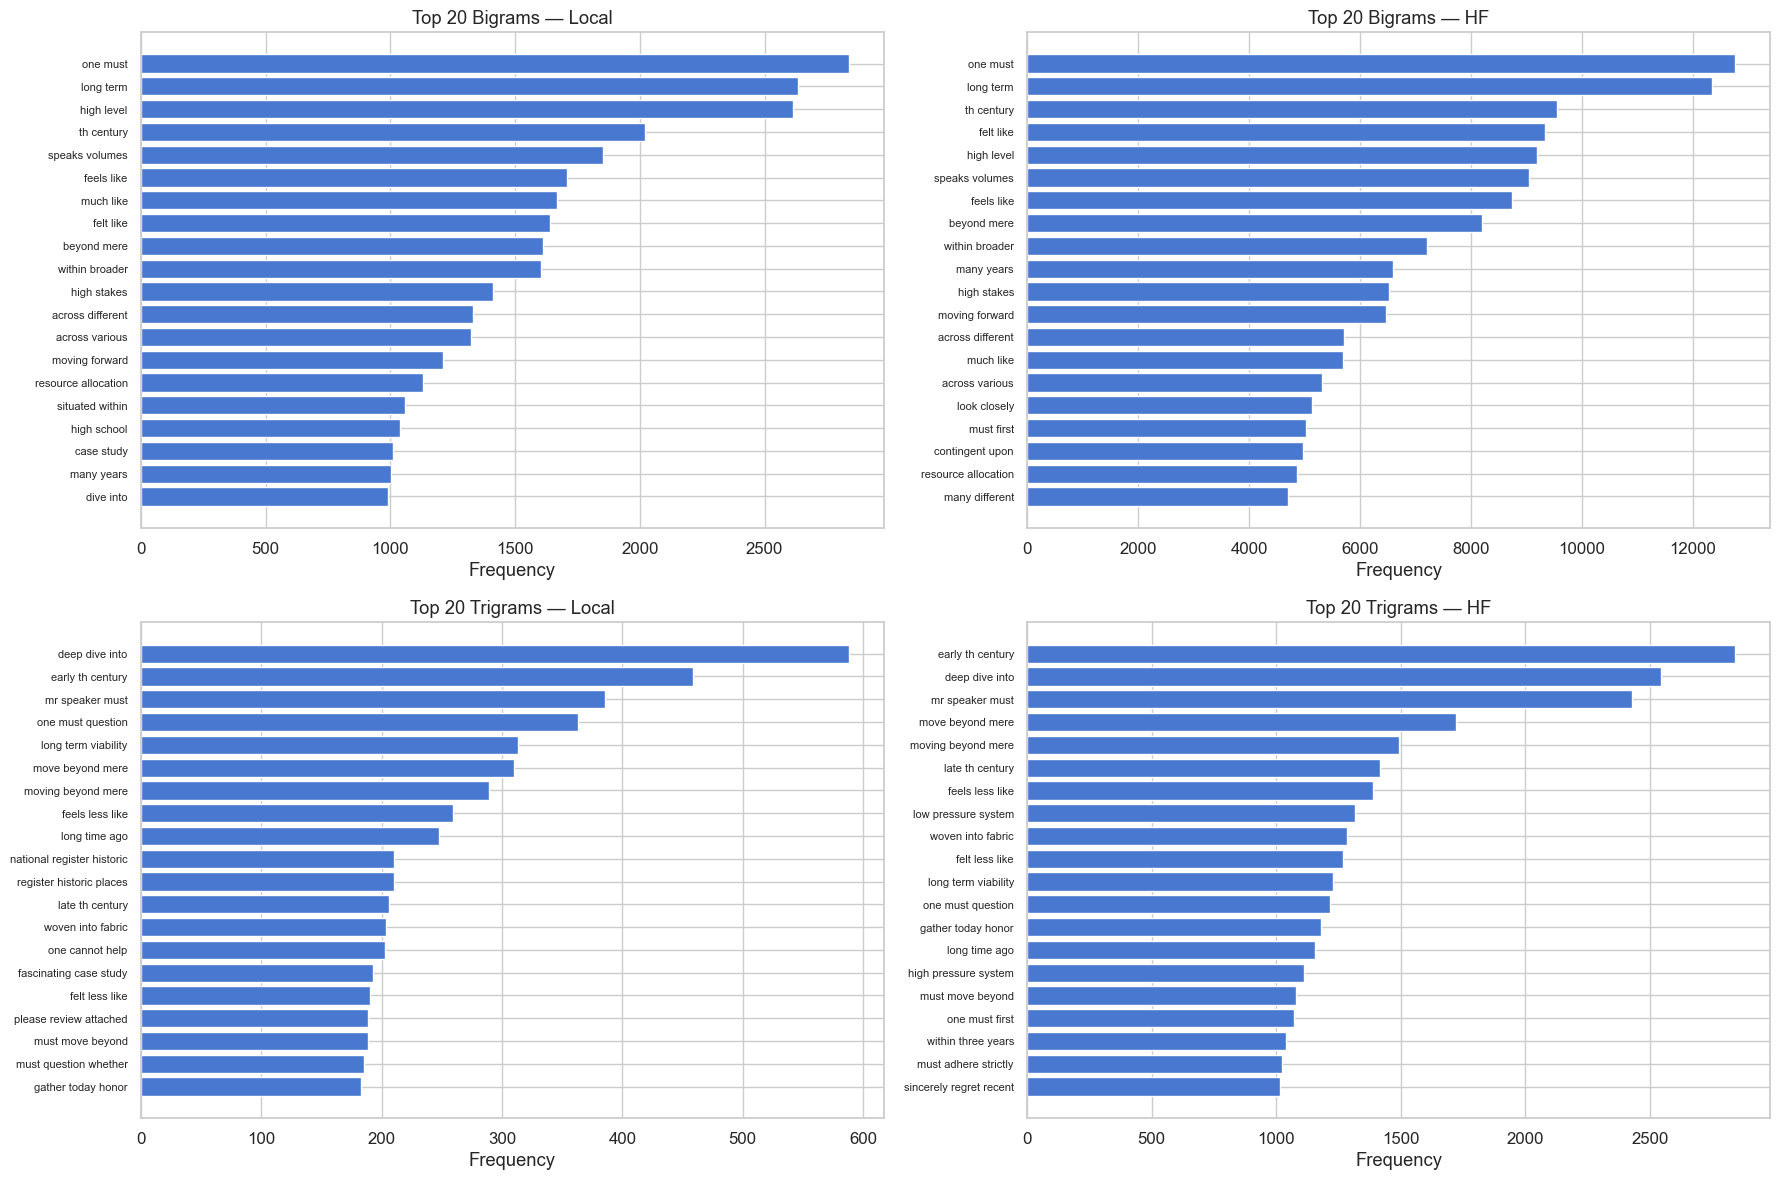

Top-5000 bigram overlap: 3,720 (74.4%)
  Local-only: 1,280
  HF-only:    1,280

Top 15 bigrams unique to new-genre texts:
  one must                         1,121
  long term                          661
  feels like                         401
  high level                         371
  th century                         353
  speaks volumes                     352
  don't miss                         350
  i'm trying                         303
  please review                      299
  deep dive                          298
  dive into                          296
  case study                         294
  resource allocation                281
  makes think                        271
  seems like                         255


In [13]:
def get_ngrams(tokens, n):
    return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

# Use no-stopword tokens for more meaningful n-grams
bigrams_local  = Counter(get_ngrams(words_local_ns, 2))
trigrams_local = Counter(get_ngrams(words_local_ns, 3))
bigrams_hf     = Counter(get_ngrams(words_hf_ns, 2))
trigrams_hf    = Counter(get_ngrams(words_hf_ns, 3))

# ── Top 20 bigrams ──
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
for ax, ngrams, title in [
    (axes[0, 0], bigrams_local, "Top 20 Bigrams — Local"),
    (axes[0, 1], bigrams_hf,    "Top 20 Bigrams — HF"),
    (axes[1, 0], trigrams_local, "Top 20 Trigrams — Local"),
    (axes[1, 1], trigrams_hf,    "Top 20 Trigrams — HF"),
]:
    top = ngrams.most_common(20)
    labels = [" ".join(ng) for ng, _ in top][::-1]
    values = [c for _, c in top][::-1]
    ax.barh(labels, values)
    ax.set(title=title, xlabel="Frequency")
    ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

# ── Bigram overlap between datasets ──
top_local_bi = set(w for w, _ in bigrams_local.most_common(5000))
top_hf_bi    = set(w for w, _ in bigrams_hf.most_common(5000))
overlap = top_local_bi & top_hf_bi
print(f"Top-5000 bigram overlap: {len(overlap):,} ({len(overlap)/5000*100:.1f}%)")
print(f"  Local-only: {len(top_local_bi - top_hf_bi):,}")
print(f"  HF-only:    {len(top_hf_bi - top_local_bi):,}")

# ── Sample unique bigrams from new genres ──
new_genre_texts = df_local[df_local["is_new_genre"]]["text"]
new_words = [w for t in new_genre_texts for w in re.findall(r"[a-z]+(?:'[a-z]+)?", t.lower()) if w not in STOPWORDS]
new_bigrams = Counter(get_ngrams(new_words, 2))
print(f"\nTop 15 bigrams unique to new-genre texts:")
for bg, c in new_bigrams.most_common(15):
    print(f"  {' '.join(bg):30s}  {c:>6,}")

## 10. Lexical Richness Comparison

Yule's K, Brunet's W, and Honoré's H per genre — measures of lexical richness beyond simple TTR.

/tmp/ipykernel_3457777/1372448385.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["Original genres", "New genres"], patch_artist=True)
/tmp/ipykernel_3457777/1372448385.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["Original genres", "New genres"], patch_artist=True)
/tmp/ipykernel_3457777/1372448385.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["Original genres", "New genres"], patch_artist=True)


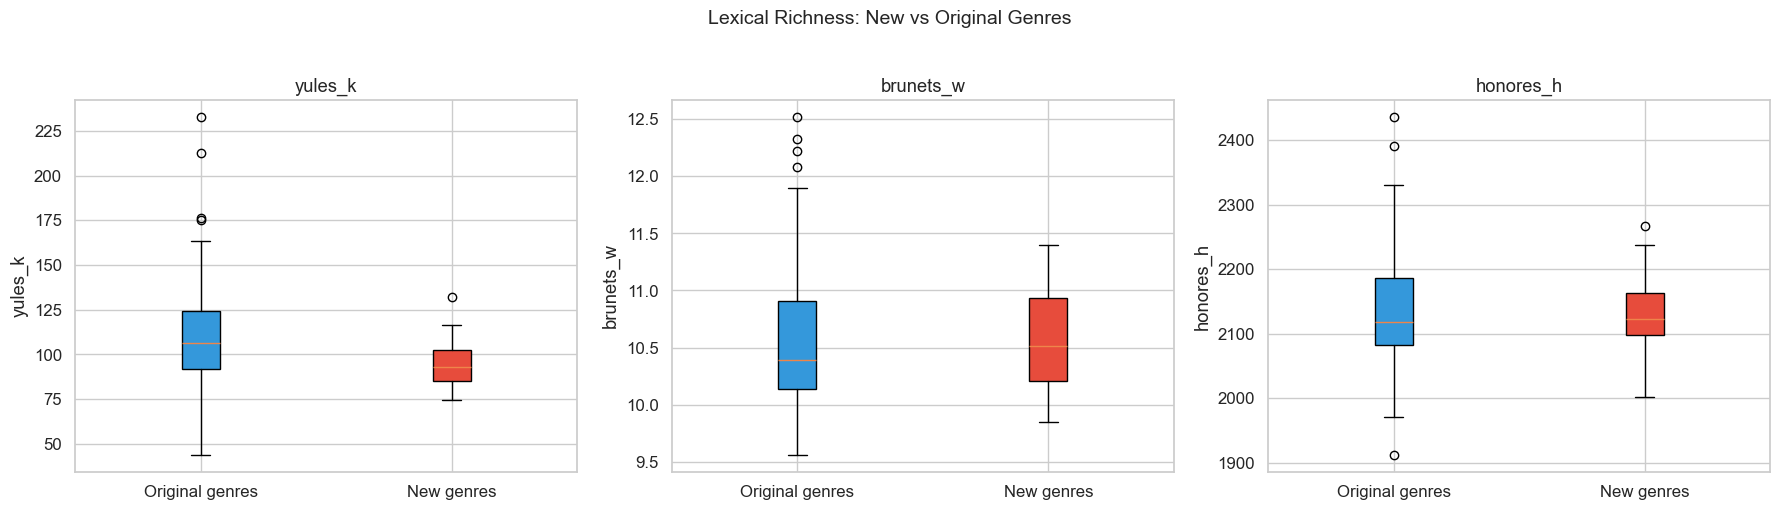

Local       Yule's K = 97.26  |  Brunet's W = 8.51  |  Honoré's H = 2839.07
HF          Yule's K = 91.47  |  Brunet's W = 9.12  |  Honoré's H = 2781.92


In [ ]:
def yules_k(tokens):
    """Yule's K — lower = richer vocabulary."""
    freq = Counter(tokens)
    N = len(tokens)
    if N <= 1:
        return 0
    freq_spectrum = Counter(freq.values())  # m -> number of words appearing m times
    M2 = sum(m * m * vm for m, vm in freq_spectrum.items())
    return 10000 * (M2 - N) / (N * N) if N > 0 else 0

def brunets_w(tokens):
    """Brunet's W — lower = richer. W = N^(V^-0.172)"""
    N = len(tokens)
    V = len(set(tokens))
    if N == 0 or V == 0:
        return 0
    return N ** (V ** -0.172)

def honores_h(tokens):
    """Honoré's H — higher = richer. H = 100*log(N) / (1 - V1/V)"""
    freq = Counter(tokens)
    N = len(tokens)
    V = len(freq)
    V1 = sum(1 for c in freq.values() if c == 1)
    if V == 0 or V1 == V:
        return 0
    return 100 * math.log(N) / (1 - V1 / V) if N > 0 else 0

# ── Per-genre lexical richness (local only) ──
genre_richness = []
for genre, grp in df_local.groupby("genre"):
    tokens = tokenize_series(grp["text"])
    genre_richness.append({
        "genre": genre,
        "is_new": genre in NEW_GENRES,
        "yules_k": yules_k(tokens),
        "brunets_w": brunets_w(tokens),
        "honores_h": honores_h(tokens),
        "ttr": ttr(tokens),
        "n_texts": len(grp),
    })

df_richness = pd.DataFrame(genre_richness).set_index("genre").sort_values("yules_k")

# ── Box plots new vs original ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric in zip(axes, ["yules_k", "brunets_w", "honores_h"]):
    data = [df_richness[~df_richness["is_new"]][metric], df_richness[df_richness["is_new"]][metric]]
    bp = ax.boxplot(data, tick_labels=["Original genres", "New genres"], patch_artist=True)
    bp["boxes"][0].set_facecolor("#3498db")
    bp["boxes"][1].set_facecolor("#e74c3c")
    ax.set(title=metric, ylabel=metric)
fig.suptitle("Lexical Richness: New vs Original Genres", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ── Global comparison ──
for tag, tokens in [("Local", words_local), ("HF", words_hf)]:
    print(f"{tag:10s}  Yule's K = {yules_k(tokens):.2f}  |  Brunet's W = {brunets_w(tokens):.2f}  |  Honoré's H = {honores_h(tokens):.2f}")

## 11. Cross-Dataset Comparative Analysis

Side-by-side metric comparison with KS tests and Mann-Whitney U tests for statistical significance.

In [15]:
# ── Statistical tests on key numeric columns ──
test_cols = ["text_words", "text_chars", "n_sentences", "n_pos", "n_neg", "n_all_labels"]

test_results = []
for col in test_cols:
    local_vals = df_local[col].dropna().values
    hf_vals = df_hf[col].dropna().values
    
    ks_stat, ks_p = sp_stats.ks_2samp(local_vals, hf_vals)
    mw_stat, mw_p = sp_stats.mannwhitneyu(local_vals, hf_vals, alternative="two-sided")
    
    test_results.append({
        "Metric": col,
        "Local mean": f"{local_vals.mean():.2f}",
        "HF mean": f"{hf_vals.mean():.2f}",
        "Δ mean": f"{local_vals.mean() - hf_vals.mean():+.2f}",
        "KS stat": f"{ks_stat:.4f}",
        "KS p-value": f"{ks_p:.2e}",
        "MW U stat": f"{mw_stat:.0f}",
        "MW p-value": f"{mw_p:.2e}",
        "Significant?": "✓" if ks_p < 0.05 else "✗",
    })

df_tests = pd.DataFrame(test_results)
display(df_tests)

# ── Also test quality metrics on the sampled subset ──
quality_test_results = []
for col in quality_cols:
    lv = df_local[col].dropna().values
    hv = df_hf[col].dropna().values
    if len(lv) > 0 and len(hv) > 0:
        ks_stat, ks_p = sp_stats.ks_2samp(lv, hv)
        quality_test_results.append({
            "Metric": col,
            "Local mean": f"{lv.mean():.4f}",
            "HF mean": f"{hv.mean():.4f}",
            "Δ mean": f"{lv.mean() - hv.mean():+.4f}",
            "KS stat": f"{ks_stat:.4f}",
            "KS p-value": f"{ks_p:.2e}",
            "Significant?": "✓" if ks_p < 0.05 else "✗",
        })

print("\nQuality metrics (sampled):")
display(pd.DataFrame(quality_test_results))

,Metric,Local mean,HF mean,Δ mean,KS stat,KS p-value,MW U stat,MW p-value,Significant?
0,text_words,41.72,42.32,-0.60,0.0321,8.62e-189,163476727812,2.04e-08,✓
1,text_chars,276.89,283.24,-6.35,0.0373,5.72e-255,161741801808,2.14e-44,✓
2,n_sentences,2.47,2.53,-0.06,0.0300,9.61e-165,160189375488,8.26e-110,✓
3,n_pos,3.80,3.77,+0.03,0.0303,2.62e-168,166829429758,1.21e-36,✓
4,n_neg,9.23,8.84,+0.39,0.0912,0.00e+00,168765704250,6.23e-93,✓
5,n_all_labels,13.03,12.61,+0.42,0.0885,0.00e+00,169392317826,9.70e-130,✓



Quality metrics (sampled):


,Metric,Local mean,HF mean,Δ mean,KS stat,KS p-value,Significant?
0,avg_word_len,5.6368,5.7085,-0.0717,0.0383,3.51e-13,✓
1,punct_ratio,0.0218,0.0203,+0.0015,0.0728,1.35e-46,✓
2,upper_ratio,0.0204,0.0162,+0.0042,0.1805,1.52e-285,✓
3,digit_ratio,0.0049,0.0029,+0.0019,0.0834,5.88e-61,✓
4,flesch_kincaid,13.0170,13.1383,-0.1213,0.0149,2.34e-02,✓
5,coleman_liau,14.4671,14.9956,-0.5284,0.0413,2.94e-15,✓


## 12. Summary Dashboard

Key findings in a single multi-panel figure: genre impact, word diversity, frequency comparison, and quality radar.

/tmp/ipykernel_3457777/3396473941.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


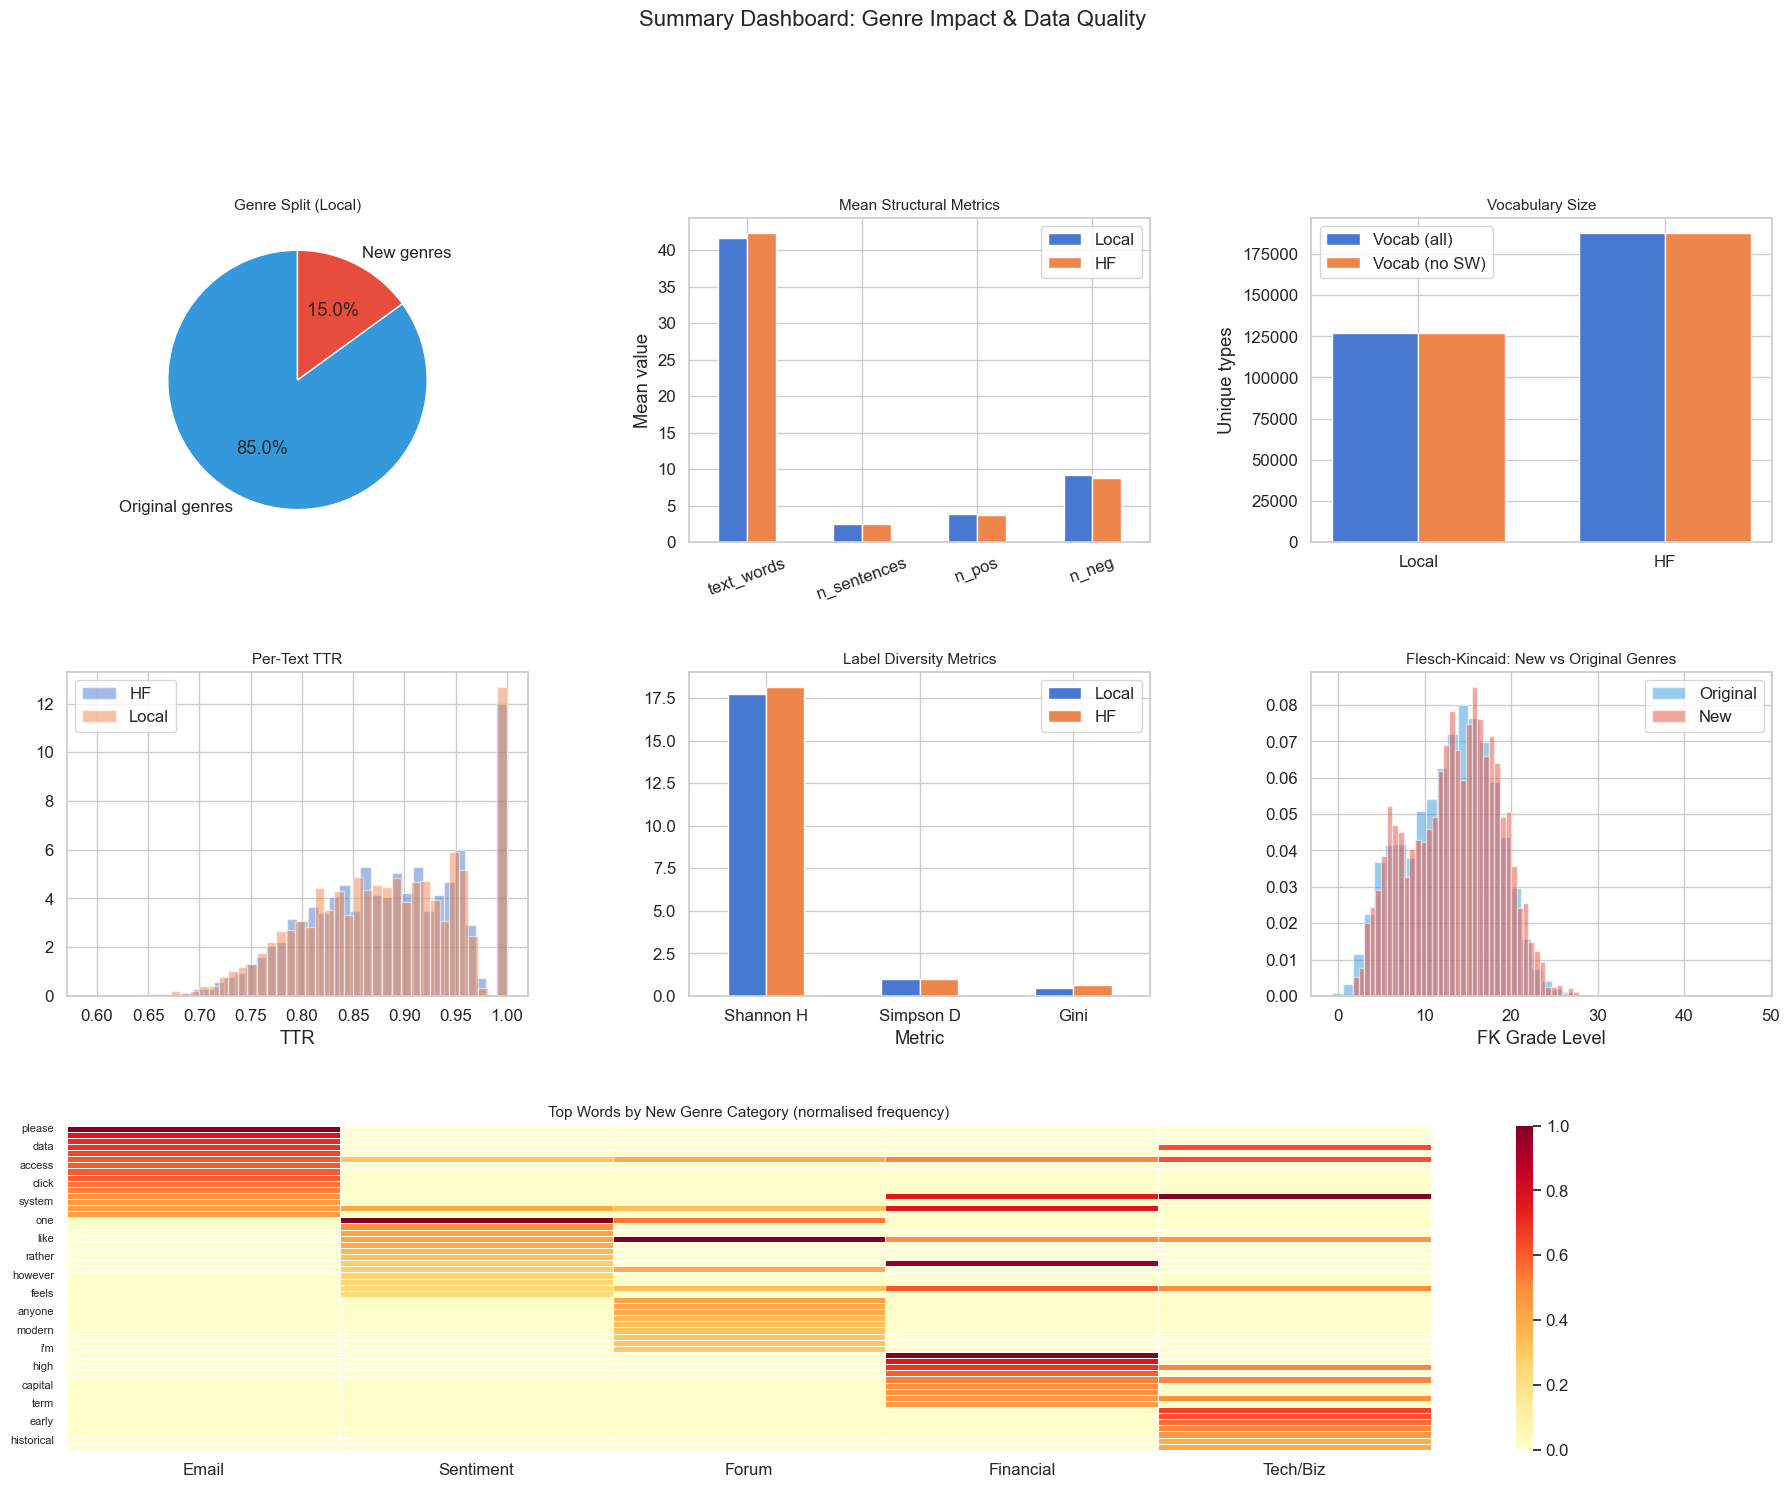


✓ Analysis complete.


In [16]:
fig = plt.figure(figsize=(22, 16))
gs = gridspec.GridSpec(3, 3, hspace=0.4, wspace=0.35)

# ── (0,0) Genre category pie ──
ax0 = fig.add_subplot(gs[0, 0])
new_count = df_local["is_new_genre"].sum()
old_count = len(df_local) - new_count
ax0.pie([old_count, new_count], labels=["Original genres", "New genres"],
        colors=["#3498db", "#e74c3c"], autopct="%1.1f%%", startangle=90)
ax0.set_title("Genre Split (Local)", fontsize=11)

# ── (0,1) Text length comparison ──
ax1 = fig.add_subplot(gs[0, 1])
means = pd.DataFrame({
    "Local": df_local[["text_words", "n_sentences", "n_pos", "n_neg"]].mean(),
    "HF": df_hf[["text_words", "n_sentences", "n_pos", "n_neg"]].mean(),
})
means.plot.bar(ax=ax1, rot=20)
ax1.set_title("Mean Structural Metrics", fontsize=11)
ax1.set_ylabel("Mean value")

# ── (0,2) Vocabulary size ──
ax2 = fig.add_subplot(gs[0, 2])
vocab_data = {
    "Vocab (all)": [len(freq_local), len(freq_hf)],
    "Vocab (no SW)": [len(freq_local_ns), len(freq_hf_ns)],
}
x = np.arange(2)
w = 0.35
for i, (label, vals) in enumerate(vocab_data.items()):
    ax2.bar(x + i*w, vals, w, label=label)
ax2.set_xticks(x + w/2)
ax2.set_xticklabels(["Local", "HF"])
ax2.set_title("Vocabulary Size", fontsize=11)
ax2.legend()
ax2.set_ylabel("Unique types")

# ── (1,0) TTR distribution ──
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(ttr_hf, bins=40, alpha=0.5, label="HF", density=True)
ax3.hist(ttr_local, bins=40, alpha=0.5, label="Local", density=True)
ax3.set_title("Per-Text TTR", fontsize=11)
ax3.set_xlabel("TTR")
ax3.legend()

# ── (1,1) Label diversity ──
ax4 = fig.add_subplot(gs[1, 1])
div_metrics = ["Cross-role %", "Shannon entropy (all)", "Simpson diversity (all)", "Gini coefficient (all)"]
# Rebuild as numeric for charting
for tag, df in [("Local", df_local), ("HF", df_hf)]:
    all_lbl = [l for ls in df["all_labels"] for l in ls]
    freq = Counter(all_lbl)
div_data = pd.DataFrame({
    "Metric": ["Shannon H", "Simpson D", "Gini"],
    "Local": [
        shannon_entropy(Counter(l for ls in df_local["all_labels"] for l in ls)),
        simpson_diversity(Counter(l for ls in df_local["all_labels"] for l in ls)),
        gini_coefficient(Counter(l for ls in df_local["all_labels"] for l in ls)),
    ],
    "HF": [
        shannon_entropy(Counter(l for ls in df_hf["all_labels"] for l in ls)),
        simpson_diversity(Counter(l for ls in df_hf["all_labels"] for l in ls)),
        gini_coefficient(Counter(l for ls in df_hf["all_labels"] for l in ls)),
    ],
})
div_data.set_index("Metric").plot.bar(ax=ax4, rot=0)
ax4.set_title("Label Diversity Metrics", fontsize=11)

# ── (1,2) Readability new vs original ──
ax5 = fig.add_subplot(gs[1, 2])
for is_new, label, color in [(False, "Original", "#3498db"), (True, "New", "#e74c3c")]:
    subset = df_local[(df_local["is_new_genre"] == is_new) & df_local["flesch_kincaid"].notna()]
    ax5.hist(subset["flesch_kincaid"], bins=40, alpha=0.5, label=label, density=True, color=color)
ax5.set_title("Flesch-Kincaid: New vs Original Genres", fontsize=11)
ax5.set_xlabel("FK Grade Level")
ax5.legend()

# ── (2,0-2) Top words heatmap — new genres ──
ax6 = fig.add_subplot(gs[2, :])
# Get top 20 words per new genre category
new_genre_categories = {
    "Email": ["email newsletter", "spam or phishing email", "corporate email thread", "automated notification email"],
    "Sentiment": ["mixed or ambivalent review", "lukewarm or tepid endorsement", "sarcastic or ironic praise"],
    "Forum": ["technical hobbyist forum post", "religious or philosophical discussion post", "off-topic or meta-discussion"],
    "Financial": ["market commentary or analysis", "financial news brief", "economic policy discussion"],
    "Tech/Biz": ["technology product news", "tech industry analysis"],
}
heatmap_data = {}
for cat, genres in new_genre_categories.items():
    texts = df_local[df_local["genre"].isin(genres)]["text"]
    tokens = [w for t in texts for w in re.findall(r"[a-z]+(?:'[a-z]+)?", t.lower()) if w not in STOPWORDS]
    top15 = [w for w, _ in Counter(tokens).most_common(15)]
    heatmap_data[cat] = {w: Counter(tokens)[w] for w in top15}

hm_df = pd.DataFrame(heatmap_data).fillna(0)
# Normalise per column for visual comparison
hm_norm = hm_df.div(hm_df.max(axis=0), axis=1)
sns.heatmap(hm_norm, ax=ax6, cmap="YlOrRd", annot=False, linewidths=0.5)
ax6.set_title("Top Words by New Genre Category (normalised frequency)", fontsize=11)
ax6.tick_params(axis="y", labelsize=8)

fig.suptitle("Summary Dashboard: Genre Impact & Data Quality", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

print("\n✓ Analysis complete.")